# Linear Regression from Scratch with PyTorch Tensors — No Autograd

In this notebook, we implement linear regression using **PyTorch tensors**, but we calculate every gradient ourselves.

## Learning objectives

By the end of the notebook, you should be able to:

1. Explain the forward pass of a linear model.
2. Derive the gradients of the mean squared error.
3. Verify that manual gradients match PyTorch autograd.
4. Download and preprocess a real dataset.
5. Implement a reusable `LinearRegressionScratch` class.
6. Train the model using manual gradient descent.
7. Evaluate the model on unseen data.

> **Important:** Autograd is used only once as a proof-of-concept oracle.  
> The complete model and training loop do **not** use `loss.backward()`, optimizers, or `torch.no_grad()`.

## 1. Mathematical model

For a batch of $n$ observations with $d$ features:

$$
X \in \mathbb{R}^{n \times d}, \qquad
w \in \mathbb{R}^{d \times 1}, \qquad
b \in \mathbb{R}
$$

The linear model is

$$
\hat{y} = Xw + b.
$$

We use mean squared error:

$$
\mathcal{L}(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{y}_i-y_i)^2.
$$

Let

$$
e = \hat{y}-y.
$$

Then the gradients are

$$
\frac{\partial \mathcal{L}}{\partial w}
=
\frac{2}{n}X^\top e,
$$

and

$$
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{2}{n}\sum_{i=1}^{n}e_i.
$$

Gradient descent updates the parameters as

$$
w \leftarrow w-\eta\frac{\partial \mathcal{L}}{\partial w},
$$

$$
b \leftarrow b-\eta\frac{\partial \mathcal{L}}{\partial b},
$$

where $\eta$ is the learning rate.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

torch.set_default_dtype(torch.float64)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


# Part I — Proof of concept

We will compare three computations:

1. A forward pass written directly with tensor operations.
2. The forward pass of `torch.nn.Linear`.
3. Manual gradients versus gradients produced by autograd.

This section uses random values so that the equivalence is structural, not tied to a particular dataset.

In [2]:
# Dimensions
n_samples = 5
n_features = 3

# Random batch and target
X_demo = torch.randn(n_samples, n_features)
y_demo = torch.randn(n_samples, 1)

# Random parameters
w_demo = torch.randn(n_features, 1)
b_demo = torch.randn(1)

print("X shape:", X_demo.shape)
print("w shape:", w_demo.shape)
print("b shape:", b_demo.shape)

X shape: torch.Size([5, 3])
w shape: torch.Size([3, 1])
b shape: torch.Size([1])


## 2. Forward pass: tensor expression vs. `torch.nn.Linear`

Our direct implementation is

$$
\hat{y}=Xw+b.
$$

PyTorch stores the weight of `nn.Linear(d, 1)` with shape $(1,d)$, so we copy $w^\top$ into the layer.

In [3]:
# Direct tensor implementation
y_hat_manual = X_demo @ w_demo + b_demo

# Equivalent PyTorch linear layer
linear_reference = torch.nn.Linear(
    in_features=n_features,
    out_features=1,
    bias=True,
    dtype=X_demo.dtype,
)

# Copy exactly the same parameters into the layer.
# This is initialization, not training.
with torch.no_grad():
    linear_reference.weight.copy_(w_demo.T)
    linear_reference.bias.copy_(b_demo)

y_hat_torch = linear_reference(X_demo)

print("Manual forward output:")
print(y_hat_manual)

print("\nTorch layer output:")
print(y_hat_torch)

print("\nMaximum absolute difference:")
print((y_hat_manual - y_hat_torch).abs().max().item())

assert torch.allclose(y_hat_manual, y_hat_torch, atol=1e-12)

Manual forward output:
tensor([[1.2619],
        [0.3969],
        [3.1925],
        [1.2584],
        [1.4611]])

Torch layer output:
tensor([[1.2619],
        [0.3969],
        [3.1925],
        [1.2584],
        [1.4611]], grad_fn=<AddmmBackward0>)

Maximum absolute difference:
0.0


## 3. Backward pass: manual calculus vs. autograd

For this one diagnostic experiment, autograd acts as a reference implementation.

We will **not** use autograd in the model that we train later.

In [4]:
# ----- Manual gradients -----
n = X_demo.shape[0]

error_manual = y_hat_manual - y_demo
loss_manual = torch.mean(error_manual**2)

dw_manual = (2.0 / n) * X_demo.T @ error_manual
db_manual = (2.0 / n) * error_manual.sum(dim=0)

# ----- Autograd reference -----
X_ref = X_demo.detach().clone()
y_ref = y_demo.detach().clone()

w_ref = w_demo.detach().clone().requires_grad_(True)
b_ref = b_demo.detach().clone().requires_grad_(True)

y_hat_ref = X_ref @ w_ref + b_ref
loss_ref = torch.mean((y_hat_ref - y_ref) ** 2)
loss_ref.backward()

print(f"Manual loss:   {loss_manual.item():.12f}")
print(f"Autograd loss: {loss_ref.item():.12f}")

print("\nManual dw:")
print(dw_manual)
print("\nAutograd dw:")
print(w_ref.grad)

print("\nManual db:")
print(db_manual)
print("\nAutograd db:")
print(b_ref.grad)

print("\nMax |dw_manual - dw_autograd|:",
      (dw_manual - w_ref.grad).abs().max().item())
print("Max |db_manual - db_autograd|:",
      (db_manual - b_ref.grad).abs().max().item())

assert torch.allclose(loss_manual, loss_ref, atol=1e-12)
assert torch.allclose(dw_manual, w_ref.grad, atol=1e-12)
assert torch.allclose(db_manual, b_ref.grad, atol=1e-12)

Manual loss:   3.115929503076
Autograd loss: 3.115929503076

Manual dw:
tensor([[ 3.2525],
        [-1.2368],
        [ 0.3165]])

Autograd dw:
tensor([[ 3.2525],
        [-1.2368],
        [ 0.3165]])

Manual db:
tensor([2.3960])

Autograd db:
tensor([2.3960])

Max |dw_manual - dw_autograd|: 2.220446049250313e-16
Max |db_manual - db_autograd|: 0.0


### Interpretation

The forward values match because both implementations calculate the same affine transformation.

The gradients match because the matrix expressions

$$
\frac{\partial \mathcal{L}}{\partial w}
=
\frac{2}{n}X^\top(\hat{y}-y)
$$

and

$$
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{2}{n}\sum_i(\hat{y}_i-y_i)
$$

are exactly the derivatives that autograd obtains by applying the chain rule.

# Part II — Download and inspect the data

We use the **Advertising** dataset associated with *An Introduction to Statistical Learning*. Each row describes advertising expenditure in different media and the resulting product sales.

Features:

- `TV`
- `radio`
- `newspaper`

Target:

- `sales`

The notebook downloads the CSV automatically and stores it in `data/Advertising.csv`.

In [5]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "Advertising.csv"

URLS = [
    "https://www.statlearning.com/s/Advertising.csv",
    "https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv",
]

if not DATA_PATH.exists():
    last_error = None
    for url in URLS:
        try:
            df_download = pd.read_csv(url)
            df_download.to_csv(DATA_PATH, index=False)
            print(f"Downloaded data from: {url}")
            break
        except Exception as exc:
            last_error = exc
    else:
        raise RuntimeError(
            "The dataset could not be downloaded from any configured URL."
        ) from last_error
else:
    print(f"Using cached file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# Some versions contain an index-like first column.
unnamed_columns = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed_columns:
    df = df.drop(columns=unnamed_columns)

# Normalize column names to lowercase.
df.columns = [c.strip().lower() for c in df.columns]

df.head()

Using cached file: data/Advertising.csv


,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nSummary:")
display(df.describe().T)

Shape: (200, 4)

Data types:
tv           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

Missing values:
tv           0
radio        0
newspaper    0
sales        0
dtype: int64

Summary:


,count,mean,std,min,25%,50%,75%,max
tv,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


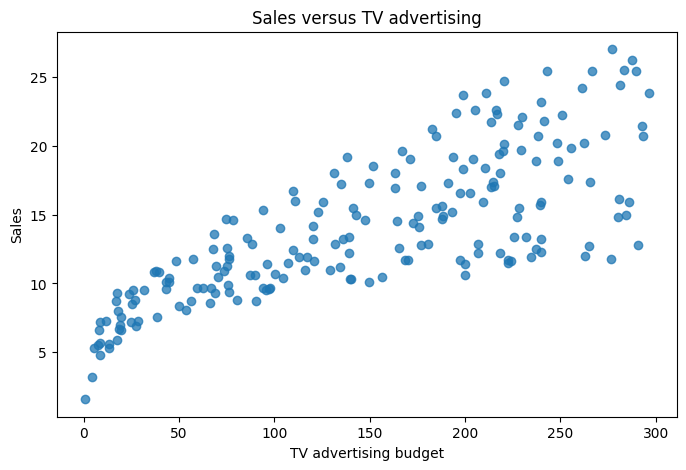

In [7]:
feature_names = ["tv", "radio", "newspaper"]
target_name = "sales"

fig = plt.figure(figsize=(8, 5))
plt.scatter(df["tv"], df[target_name], alpha=0.75)
plt.xlabel("TV advertising budget")
plt.ylabel("Sales")
plt.title("Sales versus TV advertising")
plt.show()

# Part III — Data processing with PyTorch tensors

We will:

1. Split the observations into training and test sets.
2. Fit normalization statistics using **only the training set**.
3. Standardize both features and target.
4. Convert the data to `torch.Tensor`.

For a variable $x$, standardization is

$$
x_{\text{scaled}}=\frac{x-\mu}{\sigma}.
$$

Standardizing the target is not mandatory, but it makes gradient descent easier to teach because the features and output have comparable scales.

In [8]:
def train_test_split_indices(
    n_observations: int,
    test_fraction: float = 0.20,
    seed: int = 42,
):
    if not 0.0 < test_fraction < 1.0:
        raise ValueError("test_fraction must be between 0 and 1.")

    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(n_observations, generator=generator)

    n_test = max(1, int(round(n_observations * test_fraction)))
    test_idx = permutation[:n_test]
    train_idx = permutation[n_test:]

    return train_idx, test_idx


X_all = torch.tensor(df[feature_names].to_numpy())
y_all = torch.tensor(df[[target_name]].to_numpy())

train_idx, test_idx = train_test_split_indices(
    n_observations=len(df),
    test_fraction=0.20,
    seed=SEED,
)

X_train_raw = X_all[train_idx]
X_test_raw = X_all[test_idx]
y_train_raw = y_all[train_idx]
y_test_raw = y_all[test_idx]

print("Training observations:", X_train_raw.shape[0])
print("Test observations:", X_test_raw.shape[0])

Training observations: 160
Test observations: 40


In [9]:
class StandardScalerScratch:
    def __init__(self, eps: float = 1e-12):
        self.eps = eps
        self.mean = None
        self.std = None

    def fit(self, X: torch.Tensor):
        if X.ndim != 2:
            raise ValueError("X must be a 2D tensor.")

        self.mean = X.mean(dim=0, keepdim=True)
        self.std = X.std(dim=0, keepdim=True, unbiased=False)

        if torch.any(self.std < self.eps):
            raise ValueError("At least one variable has near-zero variance.")

        return self

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        self._check_is_fitted()
        return (X - self.mean) / self.std

    def inverse_transform(self, X_scaled: torch.Tensor) -> torch.Tensor:
        self._check_is_fitted()
        return X_scaled * self.std + self.mean

    def fit_transform(self, X: torch.Tensor) -> torch.Tensor:
        return self.fit(X).transform(X)

    def _check_is_fitted(self):
        if self.mean is None or self.std is None:
            raise RuntimeError("The scaler must be fitted first.")


X_scaler = StandardScalerScratch()
y_scaler = StandardScalerScratch()

X_train = X_scaler.fit_transform(X_train_raw)
X_test = X_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_test = y_scaler.transform(y_test_raw)

print("Training feature means:", X_train.mean(dim=0))
print("Training feature standard deviations:",
      X_train.std(dim=0, unbiased=False))
print("Training target mean:", y_train.mean())
print("Training target standard deviation:",
      y_train.std(unbiased=False))

Training feature means: tensor([-1.4433e-16,  6.1062e-17,  1.3878e-18])
Training feature standard deviations: tensor([1.0000, 1.0000, 1.0000])
Training target mean: tensor(1.2212e-16)
Training target standard deviation: tensor(1.0000)


# Part IV — Linear regression class from scratch

The class contains the core components of a trainable model:

- `forward(X)`: computes predictions.
- `loss(y_hat, y)`: computes MSE.
- `backward(X, y_hat, y)`: computes gradients manually.
- `step(learning_rate)`: applies gradient descent.
- `fit(...)`: repeats forward, backward, and update operations.
- `predict(X)`: returns predictions.

No autograd graph is created because the parameters never have `requires_grad=True`.

In [10]:
class LinearRegressionScratch:
    def __init__(
        self,
        n_features: int,
        seed: int = 42,
        weight_scale: float = 0.01,
    ):
        if n_features < 1:
            raise ValueError("n_features must be positive.")

        generator = torch.Generator().manual_seed(seed)

        self.w = weight_scale * torch.randn(
            n_features,
            1,
            generator=generator,
        )
        self.b = torch.zeros(1)

        self.dw = torch.zeros_like(self.w)
        self.db = torch.zeros_like(self.b)
        self.history = []

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        self._validate_X(X)
        return X @ self.w + self.b

    @staticmethod
    def loss(y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        if y_hat.shape != y.shape:
            raise ValueError(
                f"Prediction shape {y_hat.shape} does not match "
                f"target shape {y.shape}."
            )
        return torch.mean((y_hat - y) ** 2)

    def backward(
        self,
        X: torch.Tensor,
        y_hat: torch.Tensor,
        y: torch.Tensor,
    ):
        self._validate_X(X)

        if y_hat.shape != y.shape:
            raise ValueError("y_hat and y must have the same shape.")

        n = X.shape[0]
        error = y_hat - y

        self.dw = (2.0 / n) * X.T @ error
        self.db = (2.0 / n) * error.sum(dim=0)

        return self.dw, self.db

    def step(self, learning_rate: float):
        if learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")

        # Manual gradient descent: no torch optimizer and no autograd.
        self.w -= learning_rate * self.dw
        self.b -= learning_rate * self.db

    def fit(
        self,
        X: torch.Tensor,
        y: torch.Tensor,
        epochs: int = 1000,
        learning_rate: float = 0.05,
        verbose_every: int = 100,
    ):
        if epochs < 1:
            raise ValueError("epochs must be positive.")

        self.history = []

        for epoch in range(1, epochs + 1):
            # 1. Forward
            y_hat = self.forward(X)

            # 2. Loss
            current_loss = self.loss(y_hat, y)

            # 3. Backward
            self.backward(X, y_hat, y)

            # 4. Update
            self.step(learning_rate)

            self.history.append(current_loss.item())

            if verbose_every and (
                epoch == 1
                or epoch % verbose_every == 0
                or epoch == epochs
            ):
                print(
                    f"Epoch {epoch:4d}/{epochs} | "
                    f"MSE: {current_loss.item():.8f}"
                )

        return self

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        return self.forward(X)

    def _validate_X(self, X: torch.Tensor):
        if X.ndim != 2:
            raise ValueError("X must be a 2D tensor.")
        if X.shape[1] != self.w.shape[0]:
            raise ValueError(
                f"Expected {self.w.shape[0]} features, "
                f"received {X.shape[1]}."
            )

## 4. Sanity check: the scratch model does not use autograd

In [11]:
model = LinearRegressionScratch(
    n_features=X_train.shape[1],
    seed=SEED,
)

print("w.requires_grad:", model.w.requires_grad)
print("b.requires_grad:", model.b.requires_grad)

assert model.w.requires_grad is False
assert model.b.requires_grad is False

w.requires_grad: False
b.requires_grad: False


# Part V — Train the model

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    learning_rate=0.05,
    verbose_every=100,
)

Epoch    1/1000 | MSE: 0.99251398
Epoch  100/1000 | MSE: 0.11693920
Epoch  200/1000 | MSE: 0.11693908
Epoch  300/1000 | MSE: 0.11693908
Epoch  400/1000 | MSE: 0.11693908
Epoch  500/1000 | MSE: 0.11693908


Epoch  600/1000 | MSE: 0.11693908
Epoch  700/1000 | MSE: 0.11693908


Epoch  800/1000 | MSE: 0.11693908


Epoch  900/1000 | MSE: 0.11693908
Epoch 1000/1000 | MSE: 0.11693908


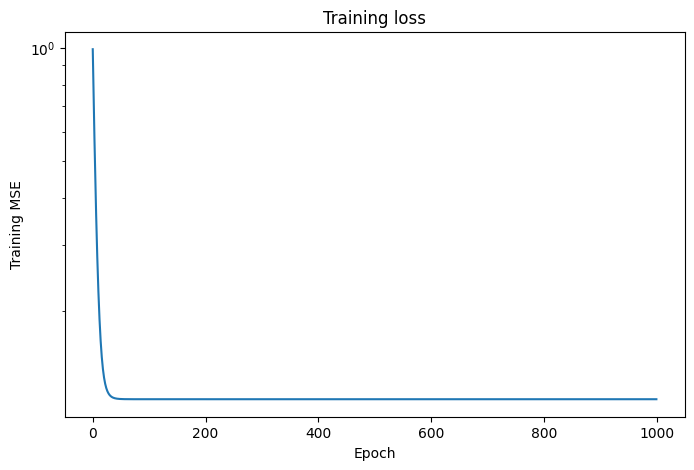

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(model.history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training loss")
plt.yscale("log")
plt.show()

# Part VI — Evaluation

We report:

$$
\operatorname{MSE}
=
\frac{1}{n}\sum_i(\hat{y}_i-y_i)^2,
$$

$$
\operatorname{RMSE}
=
\sqrt{\operatorname{MSE}},
$$

$$
R^2
=
1-
\frac{\sum_i(y_i-\hat{y}_i)^2}
{\sum_i(y_i-\bar{y})^2}.
$$

Predictions are transformed back to the original sales scale before evaluation.

In [14]:
def regression_metrics(
    y_true: torch.Tensor,
    y_pred: torch.Tensor,
):
    residual = y_true - y_pred

    mse = torch.mean(residual**2)
    rmse = torch.sqrt(mse)
    mae = torch.mean(torch.abs(residual))

    ss_res = torch.sum(residual**2)
    ss_tot = torch.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot

    return {
        "MSE": mse.item(),
        "RMSE": rmse.item(),
        "MAE": mae.item(),
        "R2": r2.item(),
    }


y_train_pred_scaled = model.predict(X_train)
y_test_pred_scaled = model.predict(X_test)

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

train_metrics = regression_metrics(y_train_raw, y_train_pred)
test_metrics = regression_metrics(y_test_raw, y_test_pred)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    index=["Train", "Test"],
)

metrics_df

,MSE,RMSE,MAE,R2
Train,2.993626,1.730210,1.302542,0.883061
Test,2.059342,1.435041,1.191692,0.936143


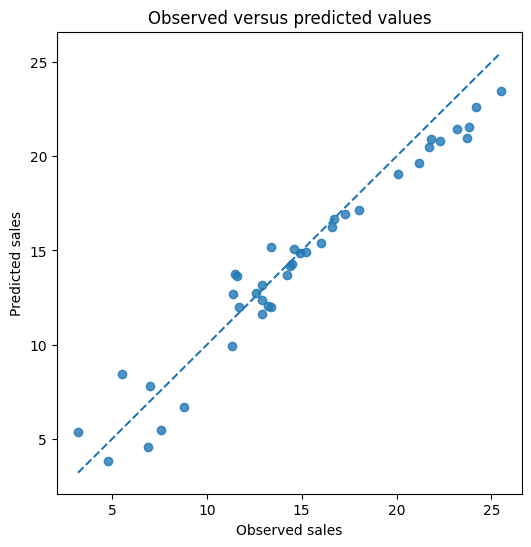

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw.squeeze(), y_test_pred.squeeze(), alpha=0.8)

minimum = min(y_test_raw.min().item(), y_test_pred.min().item())
maximum = max(y_test_raw.max().item(), y_test_pred.max().item())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Observed sales")
plt.ylabel("Predicted sales")
plt.title("Observed versus predicted values")
plt.show()

## 5. Interpret the learned coefficients in the original units

The model was trained in standardized coordinates:

$$
\hat{y}_s = X_s w_s + b_s.
$$

The equivalent coefficients in the original units are

$$
w_{\text{original},j}
=
\frac{\sigma_y}{\sigma_{X_j}}w_{s,j},
$$

and

$$
b_{\text{original}}
=
\mu_y+\sigma_y b_s
-
\sum_j \mu_{X_j}w_{\text{original},j}.
$$

In [16]:
sigma_y = y_scaler.std.squeeze()
mu_y = y_scaler.mean.squeeze()

sigma_X = X_scaler.std.squeeze()
mu_X = X_scaler.mean.squeeze()

w_original = (sigma_y / sigma_X).reshape(-1, 1) * model.w
b_original = (
    mu_y
    + sigma_y * model.b
    - (mu_X.reshape(1, -1) @ w_original).squeeze()
)

coefficient_table = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": w_original.squeeze().tolist(),
    }
)

display(coefficient_table)
print("Intercept:", b_original.item())

,feature,coefficient
0,tv,0.045427
1,radio,0.180852
2,newspaper,-0.000888


Intercept: 3.068867620169449


In [17]:
# Verify that the original-scale equation reproduces the same predictions.
y_test_pred_direct = X_test_raw @ w_original + b_original

maximum_difference = (
    y_test_pred - y_test_pred_direct
).abs().max().item()

print("Maximum prediction difference:", maximum_difference)

assert torch.allclose(
    y_test_pred,
    y_test_pred_direct,
    atol=1e-10,
)

Maximum prediction difference: 3.552713678800501e-15


# Part VII — Optional reference comparison with the closed-form solution

Linear regression also has the normal-equation solution

$$
\theta=(X^\top X)^{-1}X^\top y.
$$

Numerically, solving a linear system is preferable to explicitly calculating an inverse. We add a column of ones for the intercept and use `torch.linalg.lstsq`.

This is a **validation benchmark**, not the training procedure used by our class.

In [18]:
ones = torch.ones(X_train.shape[0], 1)
X_train_augmented = torch.cat([X_train, ones], dim=1)

least_squares_solution = torch.linalg.lstsq(
    X_train_augmented,
    y_train,
).solution

w_closed_form = least_squares_solution[:-1]
b_closed_form = least_squares_solution[-1]

print("Gradient-descent weights:")
print(model.w)
print("\nClosed-form weights:")
print(w_closed_form)

print("\nGradient-descent bias:")
print(model.b)
print("\nClosed-form bias:")
print(b_closed_form)

print(
    "\nMax parameter difference:",
    torch.max(
        torch.abs(
            torch.cat([model.w.flatten(), model.b])
            - torch.cat([w_closed_form.flatten(), b_closed_form.flatten()])
        )
    ).item(),
)

Gradient-descent weights:
tensor([[ 0.7884],
        [ 0.5188],
        [-0.0039]])

Closed-form weights:
tensor([[ 0.7884],
        [ 0.5188],
        [-0.0039]])

Gradient-descent bias:
tensor([1.6834e-16])

Closed-form bias:
tensor([2.0122e-16])

Max parameter difference: 6.661338147750939e-16


# Part VIII — Activities

## Activity 1 — Finite-difference gradient check

Approximate one component of the weight gradient using

$$
\frac{\partial \mathcal{L}}{\partial w_j}
\approx
\frac{
\mathcal{L}(w_j+\varepsilon)
-
\mathcal{L}(w_j-\varepsilon)
}{
2\varepsilon
}.
$$

Compare the numerical approximation with `model.dw[j]`.

## Activity 2 — Learning-rate experiment

Train separate models with:

- $\eta=0.001$
- $\eta=0.01$
- $\eta=0.05$
- $\eta=0.5$

Plot the four loss curves. Which values converge slowly? Does any value become unstable?

## Activity 3 — Simple linear regression

Use only the `tv` feature. Plot the resulting regression line on top of the data.

## Activity 4 — Mini-batch gradient descent

Modify `fit` so that it updates the parameters using mini-batches rather than the complete training set.

## Activity 5 — Add L2 regularization

Change the loss to

$$
\mathcal{L}_{\text{ridge}}
=
\frac{1}{n}\lVert \hat{y}-y\rVert_2^2
+
\lambda\lVert w\rVert_2^2.
$$

Derive and implement the new gradient with respect to $w$.

# Summary

The complete learning cycle was implemented manually:

$$
X
\longrightarrow
\hat{y}=Xw+b
\longrightarrow
\mathcal{L}
\longrightarrow
\left(
\frac{\partial\mathcal{L}}{\partial w},
\frac{\partial\mathcal{L}}{\partial b}
\right)
\longrightarrow
(w,b)\text{ update}.
$$

PyTorch supplied tensor operations and linear algebra, but it did not calculate the gradients or update the parameters in the scratch implementation.